In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import statsmodels.api as sm
from prophet import Prophet

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Filenames
RAW_PATH = "Twitterdatainsheets.csv"
CLEAN_PATH = "tweets_clean.csv"
FEATURES_PATH = "tweets_features.csv"
USER_ENGAGEMENT_OUTPUT = "user_engagement_summary.csv"
BEST_HOUR_OUTPUT = "user_best_hour_summary.csv"
TWEET_ENGAGEMENT_OUTPUT = "tweet_engagement_summary.csv"

# ==== PREPROCESSING ====
df = pd.read_csv(RAW_PATH, low_memory=False)
df.columns = [c.strip() for c in df.columns]

# Ensure unique column names
cols = df.columns.tolist()
seen = {}
new_cols = []
for c in cols:
    if c in seen:
        new_cols.append(f"{c}__{seen[c]}")
        seen[c] += 1
    else:
        new_cols.append(c)
        seen[c] = 1
df.columns = new_cols

# Clean
df = df.dropna(how='all').dropna(axis=1, how='all').drop_duplicates()
df.to_csv(CLEAN_PATH, index=False)

print(f"Cleaned dataset saved: {CLEAN_PATH} ({df.shape[0]} rows, {df.shape[1]} columns)")


# ==== FEATURE ENGINEERING ====
hour_col = "Hour"
weekday_col = "Weekday"
userid_col = "UserID"
tweetid_col = "TweetID"
retweet_col = "RetweetCount"
likes_col = "Likes"
text_col = "text"

df['hour_num'] = pd.to_numeric(df[hour_col], errors='coerce').fillna(0).astype(int)
df['sin_hour'] = np.sin(2 * np.pi * df['hour_num'] / 24.0)
df['cos_hour'] = np.cos(2 * np.pi * df['hour_num'] / 24.0)

df['text_len'] = df[text_col].astype(str).str.len()
df['num_hashtags'] = df[text_col].astype(str).str.count(r'#\w+')
df['num_mentions'] = df[text_col].astype(str).str.count(r'@\w+')
df['num_urls'] = df[text_col].astype(str).str.contains('http').astype(int)

user_aggs = df.groupby(userid_col).agg({
    likes_col: ['mean','median','std'],
    retweet_col: ['mean','median','std'],
    tweetid_col: ['count']
})

user_aggs.columns = [f'{a}_{b}' for a, b in user_aggs.columns]
user_aggs = user_aggs.reset_index()
df = df.merge(user_aggs, left_on=userid_col, right_on=userid_col, how='left')

df['log1p_retweet_count'] = np.log1p(pd.to_numeric(df[retweet_col], errors='coerce').fillna(0))

df.to_csv(FEATURES_PATH, index=False)
print(f"Feature-engineered data saved: {FEATURES_PATH}")


# ==== ENGAGEMENT SCORE ====
df[retweet_col] = pd.to_numeric(df[retweet_col], errors='coerce').fillna(0)
df[likes_col] = pd.to_numeric(df[likes_col], errors='coerce').fillna(0)
df['engagement_score'] = df[likes_col] * 1.2 + df[retweet_col] * 1.5


# ==== MACHINE LEARNING MODEL: XGBOOST PREDICTION ====
feature_cols = [
    'text_len','num_hashtags','num_mentions','num_urls',
    'sin_hour','cos_hour','Likes_mean','RetweetCount_mean'
]
df_ml = df[feature_cols + ['engagement_score']].dropna()

X = df_ml[feature_cols]
y = df_ml['engagement_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
print("\nXGBoost Model Performance:")
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("R² Score:", r2_score(y_test, xgb_pred))


# ==== STATS MODELS REGRESSION ====
X_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_sm).fit()
print("\nStatsModels Regression Summary:")
print(model.summary())


# ==== PROPHET TIME-SERIES FORECAST ====
df_prophet = df[['hour_num','engagement_score']].copy()
df_prophet = df_prophet.groupby('hour_num').mean().reset_index()

# Create a dummy date for Prophet to work with hourly data
df_prophet['ds'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_prophet['hour_num'], unit='H')
df_prophet = df_prophet.rename(columns={'engagement_score': 'y'})
df_prophet = df_prophet[['ds', 'y']] # Ensure 'ds' and 'y' are in the correct order

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=24, freq='H')
forecast = prophet_model.predict(future)

print("\nProphet forecasting complete.")


# ==== DEEP LEARNING: PYTORCH MODEL ====
X_dl = torch.tensor(X.values, dtype=torch.float32)
y_dl = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)

dataset = TensorDataset(X_dl, y_dl)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

class EngagementNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(len(feature_cols), 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

net = EngagementNN()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(5):
    for batch_x, batch_y in loader:
        pred = net(batch_x)
        loss = loss_fn(pred, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

print("PyTorch Deep Learning Model Trained.")


# ==== USER-LEVEL STATS ====
user_stats = df.groupby(userid_col).agg(
    num_tweets=(tweetid_col, "count"),
    total_likes=(likes_col, "sum"),
    total_retweets=(retweet_col, "sum"),
    avg_likes=(likes_col, "mean"),
    avg_retweets=(retweet_col, "mean"),
    avg_engagement=("engagement_score", "mean"),
)
user_stats.to_csv(USER_ENGAGEMENT_OUTPUT)


# ==== BEST POSTING HOUR ====
per_hour = df.groupby([userid_col, 'hour_num']).agg(
    avg_hour_engagement=("engagement_score", "mean"),
    tweet_count=(tweetid_col, "count")
).reset_index()

best_hour = per_hour.loc[
    per_hour.groupby(userid_col)["avg_hour_engagement"].idxmax()
].sort_values(userid_col)

best_hour.rename(columns={'hour_num': "best_hour"}, inplace=True)
best_hour.to_csv(BEST_HOUR_OUTPUT, index=False)


# ==== TOP TWEETS ====
tweet_scores = df[[tweetid_col, userid_col, "engagement_score", hour_col]].copy()
tweet_scores = tweet_scores.sort_values("engagement_score", ascending=False)
tweet_scores.head(100).to_csv(TWEET_ENGAGEMENT_OUTPUT, index=False)


# ==== SUMMARY ====
best_posting_hour = (
    df.groupby('hour_num')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

if weekday_col in df.columns:
    df['weekday_str'] = df[weekday_col].astype(str).str.strip()
    best_posting_day = df.groupby('weekday_str')['engagement_score'].mean().sort_values(ascending=False)
else:
    best_posting_day = best_posting_hour

summary = {
    "Total Tweets": len(df),
    "Total Users": df[userid_col].nunique(),
    "Top 10 Highest Engagement Tweets":
        df.sort_values("engagement_score", ascending=False)
        [[tweetid_col, userid_col, 'engagement_score']].head(10),
    "Best Posting Hour (Overall)": int(best_posting_hour.index[0]),
    "Best Posting Day (Overall)": str(best_posting_day.index[0])
}

print("\n==================== FINAL PROJECT SUMMARY ====================\n")
for k, v in summary.items():
    print(f"{k}:")
    print(v, "\n")

# Top 5 users by tweet count
print("\nTop 5 users by tweet count:")
if "TweetID_count" in df.columns:
    print(df.groupby(userid_col)['TweetID_count'].max().sort_values(ascending=False).head(5))
else:
    # If TweetID_count didn't exist, calculate it
    user_tweet_count = df.groupby(userid_col)[tweetid_col].count().sort_values(ascending=False)
    print(user_tweet_count.head(5))

# Top 5 tweets by retweet count
print("\nTop 5 tweets by retweet count:")
print(df.sort_values(retweet_col, ascending=False)[[tweetid_col, userid_col, retweet_col]].head(5))

# Top 5 tweets by engagement
print("\nTop 5 tweets by engagement:")
print(df.sort_values("engagement_score", ascending=False)[[tweetid_col, userid_col, "engagement_score", hour_col]].head(5))

# Best posting hour per user (top 5)
print("\nBest posting hour per user (top 5):")
print(best_hour.head(5))

# User engagement stats (top 5 users)
print("\nUser engagement stats (top 5):")
print(user_stats.head())


Cleaned dataset saved: tweets_clean.csv (206295 rows, 15 columns)
Feature-engineered data saved: tweets_features.csv

XGBoost Model Performance:
MSE: 472.481165031569
R² Score: 0.776631622762505

StatsModels Regression Summary:
                            OLS Regression Results                            
Dep. Variable:       engagement_score   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                 5.394e+04
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:33:12   Log-Likelihood:            -4.1887e+05
No. Observations:               75000   AIC:                         8.377e+05
Df Residuals:                   74991   BIC:                         8.378e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                        

/tmp/ipython-input-886995638.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df_prophet['ds'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_prophet['hour_num'], unit='H')
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(



Prophet forecasting complete.
Epoch 1: Loss = 1092.6005
Epoch 2: Loss = 719.1227
Epoch 3: Loss = 923.1706
Epoch 4: Loss = 22397.9805
Epoch 5: Loss = 2075.4954
PyTorch Deep Learning Model Trained.

==================== FINAL PROJECT SUMMARY ====================

Total Tweets:
206295 

Total Users:
33213 

Top 10 Highest Engagement Tweets:
                     TweetID         UserID  engagement_score
52937  tw-700865627364392960   tw-552279964           39190.5
71829  tw-707929034768850944  tw-2240126377           19792.5
71867  tw-707941144051654656  tw-2240126377            3097.5
63727  tw-704537807935549441    tw-66780587            1173.0
33512  tw-695374760021090304    tw-66780587             955.5
69262  tw-707040101839167488       tw-48443             948.0
4872   tw-685195764813844481    tw-66780587             930.0
99941  tw-716317763963199489  tw-2794261161             924.0
98827  tw-715854610217439232  tw-2440575398             907.5
97035  tw-715502429182136320  tw-105683

Dataset loaded: (206295, 31)


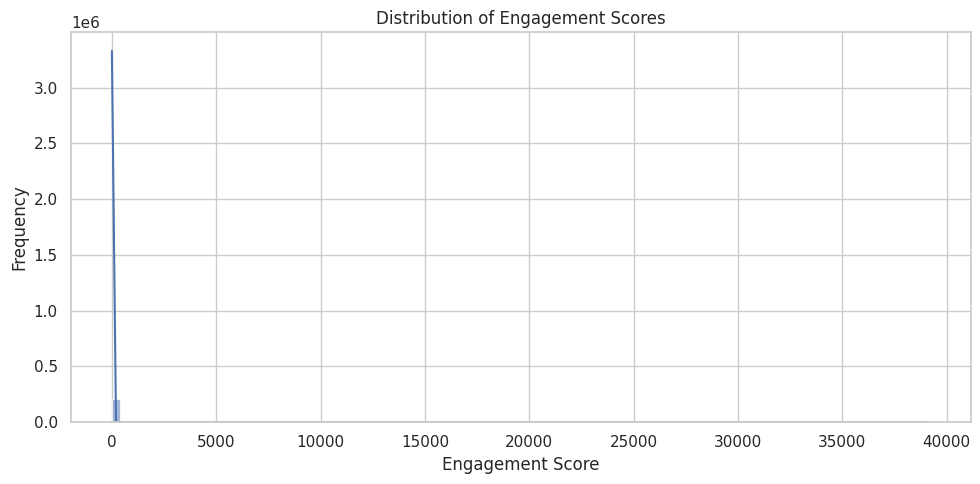

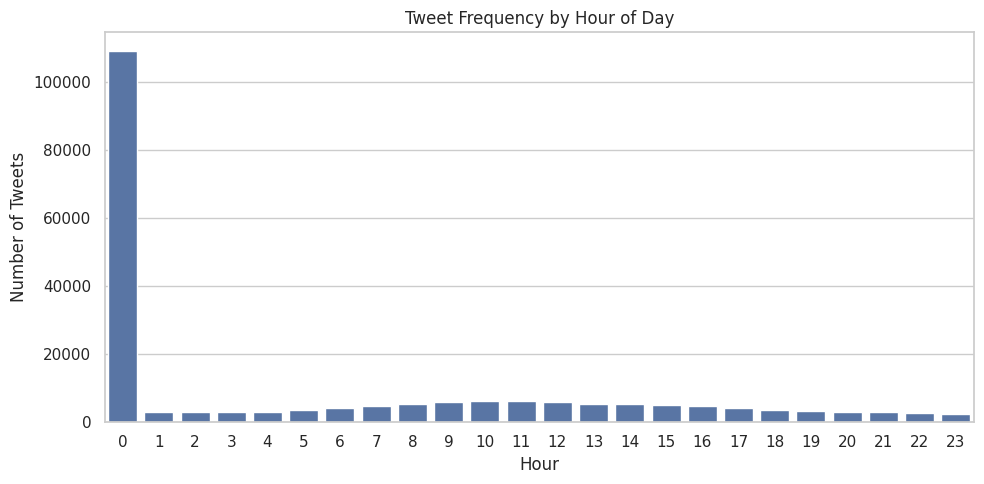

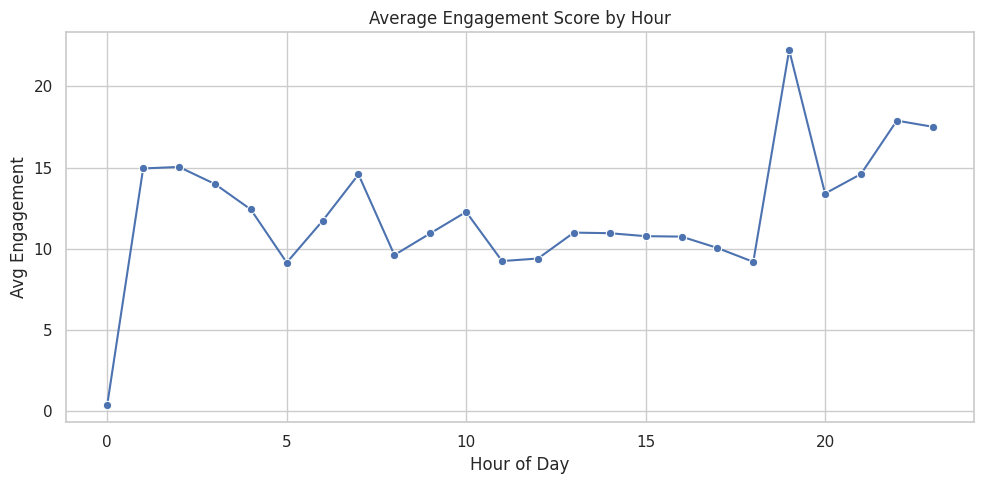

/tmp/ipython-input-690144462.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.values, y=top_users.index, palette="viridis")


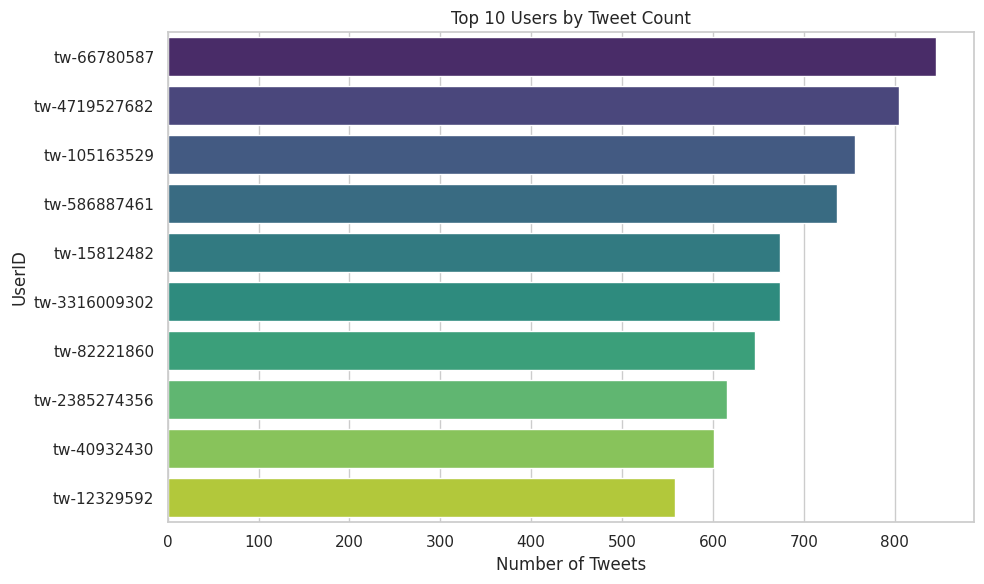

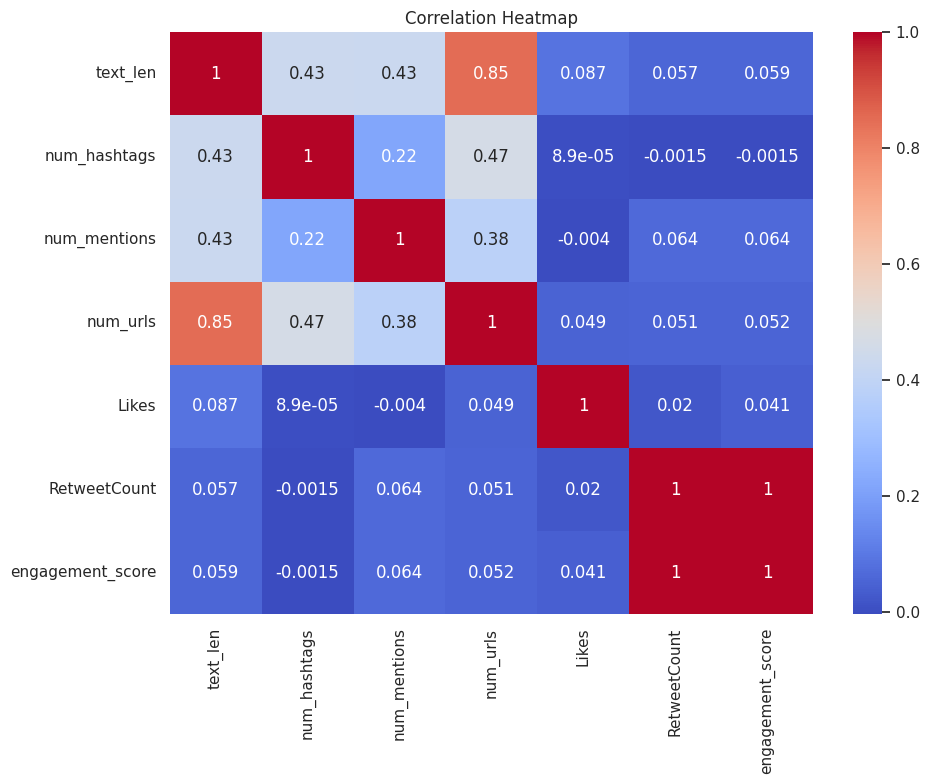

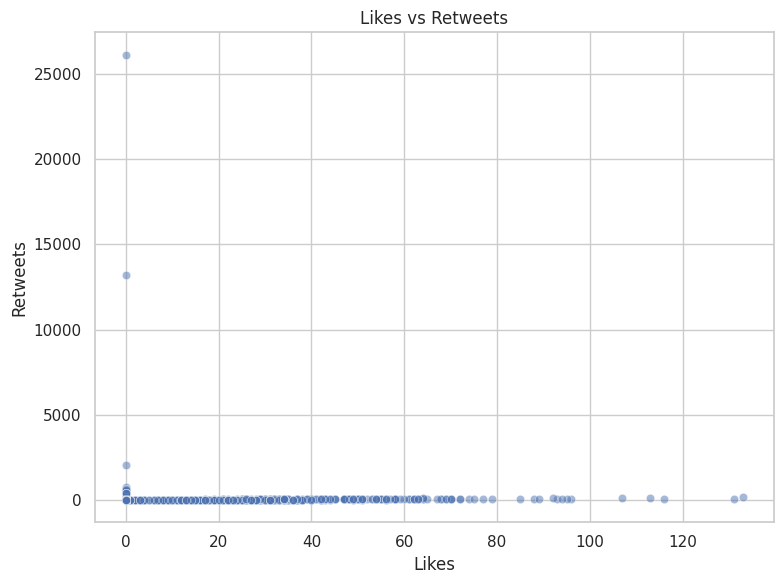

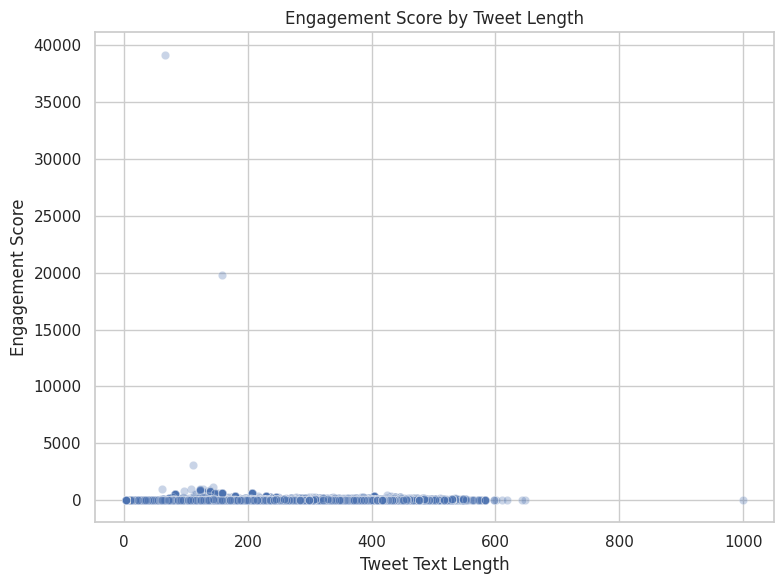

/tmp/ipython-input-690144462.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hour_num", y="engagement_score", data=top_hours, palette="coolwarm")


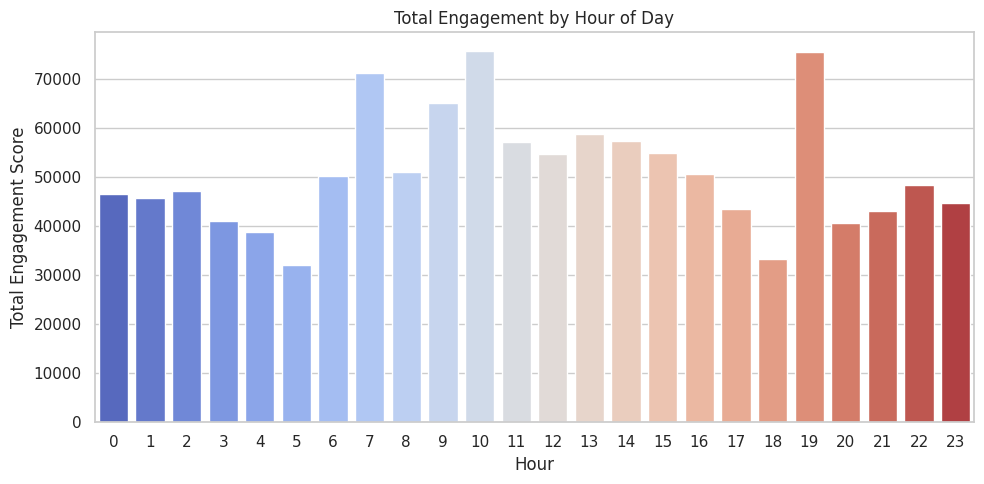

All visualizations generated successfully!


In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("tweets_features.csv", low_memory=False)

# Ensure 'Likes' and 'RetweetCount' are numeric before calculating engagement_score
df['RetweetCount'] = pd.to_numeric(df['RetweetCount'], errors='coerce').fillna(0)
df['Likes'] = pd.to_numeric(df['Likes'], errors='coerce').fillna(0)
df['engagement_score'] = df['Likes'] * 1.2 + df['RetweetCount'] * 1.5

# Set style
sns.set(style="whitegrid")

print("Dataset loaded:", df.shape)

# ===========================
# 1. Engagement Score Distribution
# ===========================
plt.figure(figsize=(10,5))
sns.histplot(df['engagement_score'], bins=100, kde=True)
plt.title("Distribution of Engagement Scores")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===========================
# 2. Tweet Frequency by Hour
# ===========================
plt.figure(figsize=(10,5))
sns.countplot(x=df['hour_num'])
plt.title("Tweet Frequency by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

# ===========================
# 3. Average Engagement Per Hour
# ===========================
hour_eng = df.groupby("hour_num")["engagement_score"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hour_eng, x="hour_num", y="engagement_score", marker='o')
plt.title("Average Engagement Score by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Engagement")
plt.tight_layout()
plt.show()

# ===========================
# 4. Top 10 Users by Tweet Count
# ===========================
top_users = df['UserID'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_users.values, y=top_users.index, palette="viridis")
plt.title("Top 10 Users by Tweet Count")
plt.xlabel("Number of Tweets")
plt.ylabel("UserID")
plt.tight_layout()
plt.show()

# ===========================
# 5. Correlation Heatmap
# ===========================
plt.figure(figsize=(10,8))
sns.heatmap(df[['text_len','num_hashtags','num_mentions','num_urls',
                'Likes','RetweetCount','engagement_score']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ===========================
# 6. Likes vs Retweets Scatter Plot
# ===========================
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Likes"], y=df["RetweetCount"], alpha=0.5)
plt.title("Likes vs Retweets")
plt.xlabel("Likes")
plt.ylabel("Retweets")
plt.tight_layout()
plt.show()

# ===========================
# 7. Engagement Score vs Tweet Length
# ===========================
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["text_len"], y=df["engagement_score"], alpha=0.3)
plt.title("Engagement Score by Tweet Length")
plt.xlabel("Tweet Text Length")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()

# ===========================
# 8. Total Engagement by Hour
# ===========================
top_hours = df.groupby("hour_num")["engagement_score"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x="hour_num", y="engagement_score", data=top_hours, palette="coolwarm")
plt.title("Total Engagement by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Engagement Score")
plt.tight_layout()
plt.show()

print("All visualizations generated successfully!")
